## 1. Data Loading and Environment Setup

This section initialises the analytical environment and loads the processed ML ready dataset. A dynamic path detection mechanism ensures portability across different computing environments, facilitating reproducible research and collaborative workflows.

In [1]:
# Step 1: Setup and Automatic Dataset Loading

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Plotting & Pandas display settings
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# Find project root by walking up until a folder containing `data/` is found
def find_project_root(marker: str = "data") -> Path:
    cwd = Path.cwd()
    for path in (cwd, *cwd.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")


PROJECT_ROOT = find_project_root()

# Ensure src imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessor import temporal_splits

# Load config (used by all ML baselines)
CONFIG_PATH = PROJECT_ROOT / "configs" / "hybrid.yaml"
config = yaml.safe_load(CONFIG_PATH.read_text())
feature_cols = config["features"]["feature_cols"]
target_cols = config["features"]["target_cols"]

# Construct path to processed dataset inside repo
DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset from: {DATA_PATH}")
print("Shape:", df.shape)

# Parse date and sort
if "date" not in df.columns:
    raise ValueError("'date' column not found in dataset")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Define temporal splits (aligned to hybrid.yaml)
train_end = pd.to_datetime(config["data"]["train_end"])
val_end = pd.to_datetime(config["data"]["val_end"])
train_mask, val_mask, test_mask = temporal_splits(df, train_end, val_end)

# Build tabular ML splits
X = df[feature_cols]
y = df[target_cols]

X_train = X[train_mask.values]
X_val = X[val_mask.values]
X_test = X[test_mask.values]

y_train = y[train_mask.values]
y_val = y[val_mask.values]
y_test = y[test_mask.values]

test_dates = df.loc[test_mask, "date"].copy()

print(f"Train: {df[train_mask]['date'].min().date()} → {df[train_mask]['date'].max().date()} ({train_mask.sum()} samples)")
print(f"Val  : {df[val_mask]['date'].min().date()} → {df[val_mask]['date'].max().date()} ({val_mask.sum()} samples)")
print(f"Test : {df[test_mask]['date'].min().date()} → {df[test_mask]['date'].max().date()} ({test_mask.sum()} samples)")
print("Features:", len(feature_cols), "Targets:", target_cols)


df.head()

Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)
Train: 1997-12-01 → 2017-12-01 (241 samples)
Val  : 2018-01-01 → 2021-12-01 (48 samples)
Test : 2022-01-01 → 2025-02-01 (38 samples)
Features: 14 Targets: ['cpi_t1', 'cpi_t3', 'cpi_t5']


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


### Random Forest Baseline Model (Multi-Output Forecasting)

Following the temporal data preparation and split strategy defined in Step 1, a Random Forest regressor is implemented as the machine-learning baseline model. All feature and target definitions are sourced directly from the project configuration file (`hybrid.yaml`) to ensure consistency across baseline, benchmark, and hybrid models.

The baseline is formulated as a **multi-output regression problem**, where a single Random Forest model is trained to jointly forecast inflation at multiple horizons. Specifically, the model produces simultaneous predictions for **t+1, t+3, and t+5** inflation outcomes from the same set of lagged macroeconomic features.

This design choice provides a strong yet methodologically simple benchmark. Random Forest is well-suited to tabular macroeconomic data due to its ability to capture non-linear interactions, robustness to multicollinearity, and minimal distributional assumptions. By avoiding horizon-specific tuning and maintaining a unified training procedure, the baseline establishes a fair point of comparison against more complex benchmark models and the proposed hybrid architectures.

Model performance is evaluated separately for each forecast horizon and data split (training, validation, and test) using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **coefficient of determination (R²)**. In addition to numerical metrics, visual diagnostics—scatter plots and time-series comparisons of actual versus predicted values—are employed to assess goodness-of-fit, bias, and temporal stability.


In [2]:
# ------------------------------------------------------------
# Step 2: Random Forest Baseline (Multi-Output) - Train & Predict
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Sanity checks
assert len(feature_cols) > 0, "feature_cols is empty. Check configs/hybrid.yaml."
assert len(target_cols) > 0, "target_cols is empty. Check configs/hybrid.yaml."
print("Targets:", target_cols)

# Define baseline RF hyperparameters (keep modest; this is a baseline)
rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Multi-output wrapper: one RF estimator per target internally
rf_model = MultiOutputRegressor(rf_base)

# Fit
rf_model.fit(X_train, y_train)

# Predict (shape: [n_samples, n_targets])
rf_pred_train = rf_model.predict(X_train)
rf_pred_val   = rf_model.predict(X_val)
rf_pred_test  = rf_model.predict(X_test)

print("Pred shapes:")
print(" train:", rf_pred_train.shape, "val:", rf_pred_val.shape, "test:", rf_pred_test.shape)

# Convert predictions to DataFrames for easier indexing/plotting
rf_pred_train_df = pd.DataFrame(rf_pred_train, columns=target_cols, index=y_train.index)
rf_pred_val_df   = pd.DataFrame(rf_pred_val,   columns=target_cols, index=y_val.index)
rf_pred_test_df  = pd.DataFrame(rf_pred_test,  columns=target_cols, index=y_test.index)

# Also keep y as DataFrames (in case y came through as ndarray in some runs)
y_train_df = pd.DataFrame(y_train, columns=target_cols, index=X_train.index)
y_val_df   = pd.DataFrame(y_val,   columns=target_cols, index=X_val.index)
y_test_df  = pd.DataFrame(y_test,  columns=target_cols, index=X_test.index)

display(rf_pred_test_df.head())


Targets: ['cpi_t1', 'cpi_t3', 'cpi_t5']
Pred shapes:
 train: (241, 3) val: (48, 3) test: (38, 3)


,cpi_t1,cpi_t3,cpi_t5
289,4.316878,3.315816,3.015483
290,4.231144,3.420499,3.283458
291,4.228088,3.324029,3.333284
292,4.234507,3.321480,3.211415
293,4.240285,3.314335,3.207893


### Random Forest Baseline Evaluation and Diagnostic Analysis

Model performance is evaluated across training, validation, and test splits for each forecast horizon (t+1, t+3, t+5) using three complementary error metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Reporting metrics per horizon and split enables a detailed assessment of forecast degradation with increasing horizon length and potential overfitting.

In addition to numerical evaluation, two forms of visual diagnostics are employed. First, scatter plots of actual versus predicted values are used to assess overall goodness-of-fit, bias, and variance, with a 45-degree reference line indicating ideal predictions. Second, time-series line plots compare actual and predicted inflation trajectories over time, allowing inspection of temporal alignment, lag effects, and regime shifts.

All evaluation outputs, including metrics tables and figures, are saved as artifacts to ensure reproducibility and to support comparative analysis in the dedicated evaluation notebook.


In [3]:
# ------------------------------------------------------------
# Step 3: Evaluation Metrics (MAE, RMSE, R²) + Save Artifacts
# ------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

records = []

def collect_metrics(y_true_df, y_pred_df, split_name):
    for tgt in target_cols:
        records.append({
            "split": split_name,
            "horizon": tgt,
            "mae": mean_absolute_error(y_true_df[tgt], y_pred_df[tgt]),
            "rmse": np.sqrt(mean_squared_error(y_true_df[tgt], y_pred_df[tgt])),
            "r2": r2_score(y_true_df[tgt], y_pred_df[tgt])
        })

collect_metrics(y_train_df, rf_pred_train_df, "train")
collect_metrics(y_val_df,   rf_pred_val_df,   "validation")
collect_metrics(y_test_df,  rf_pred_test_df,  "test")

rf_metrics_df = pd.DataFrame(records)

display(rf_metrics_df)

# Save metrics artifact
metrics_path = ARTIFACTS_DIR / "rf_baseline_metrics.csv"
rf_metrics_df.to_csv(metrics_path, index=False)

print(f"Saved metrics to: {metrics_path}")


,split,horizon,mae,rmse,r2
0,train,cpi_t1,0.102850,0.139717,0.984412
1,train,cpi_t3,0.133904,0.191781,0.970670
2,train,cpi_t5,0.147466,0.217720,0.962227
3,validation,cpi_t1,0.337360,0.462453,0.853403
4,validation,cpi_t3,0.724039,1.061725,0.512352
5,validation,cpi_t5,1.311940,1.821880,0.213368
6,test,cpi_t1,2.724043,3.713118,-0.273663
7,test,cpi_t3,3.068823,4.148059,-0.545363
8,test,cpi_t5,3.043765,4.116411,-0.570738


Saved metrics to: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\artifacts\rf_baseline_metrics.csv


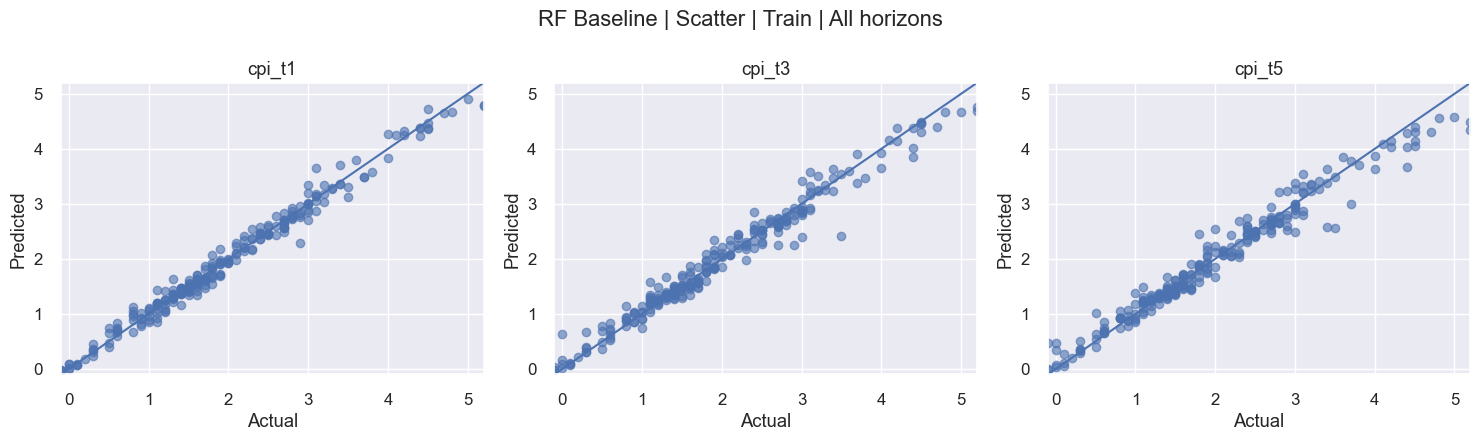

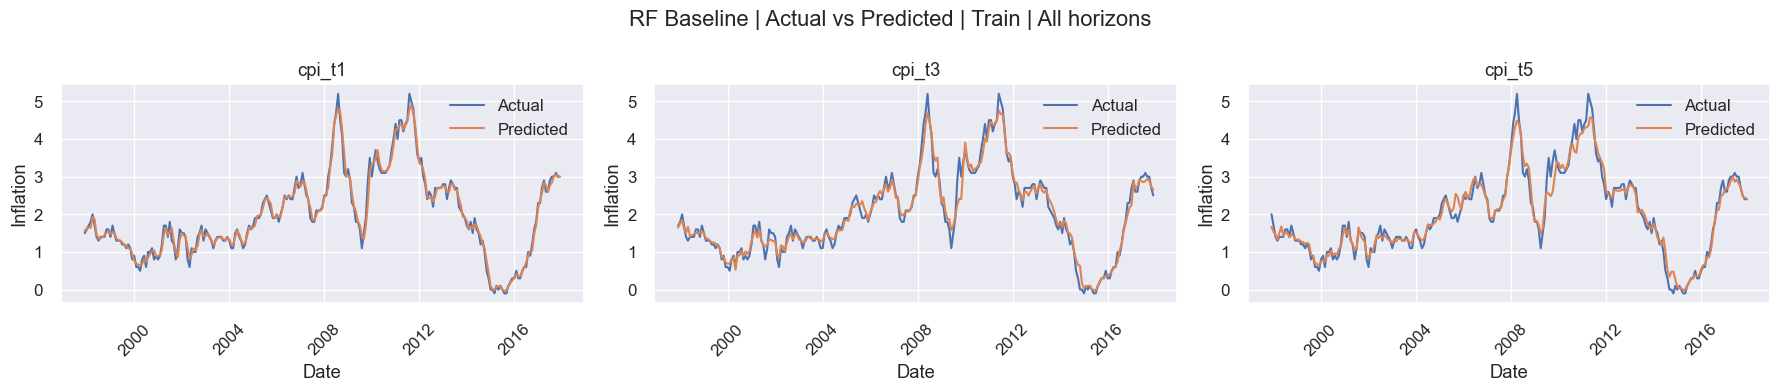

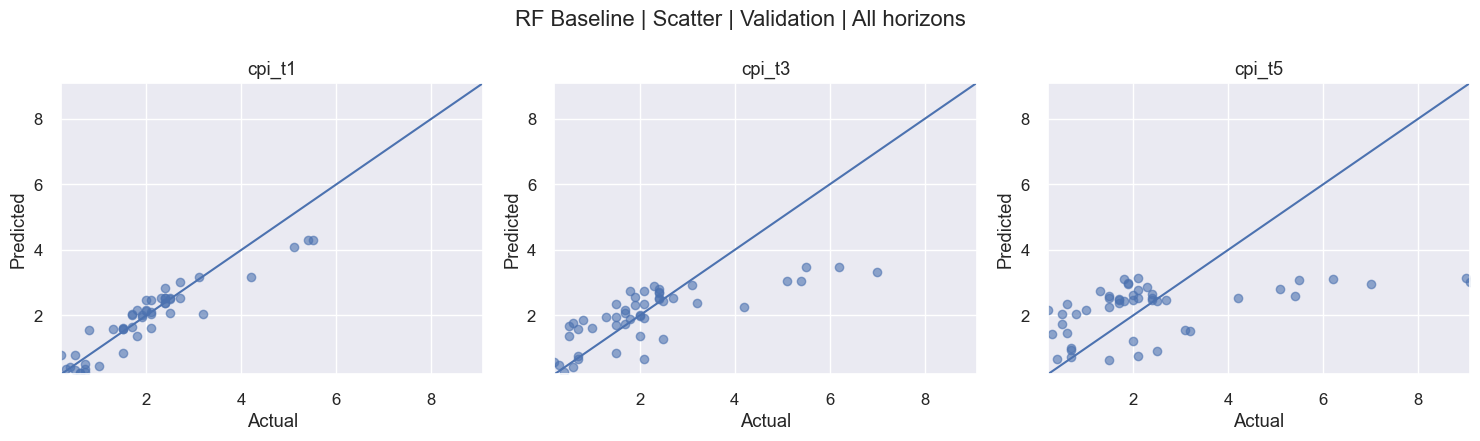

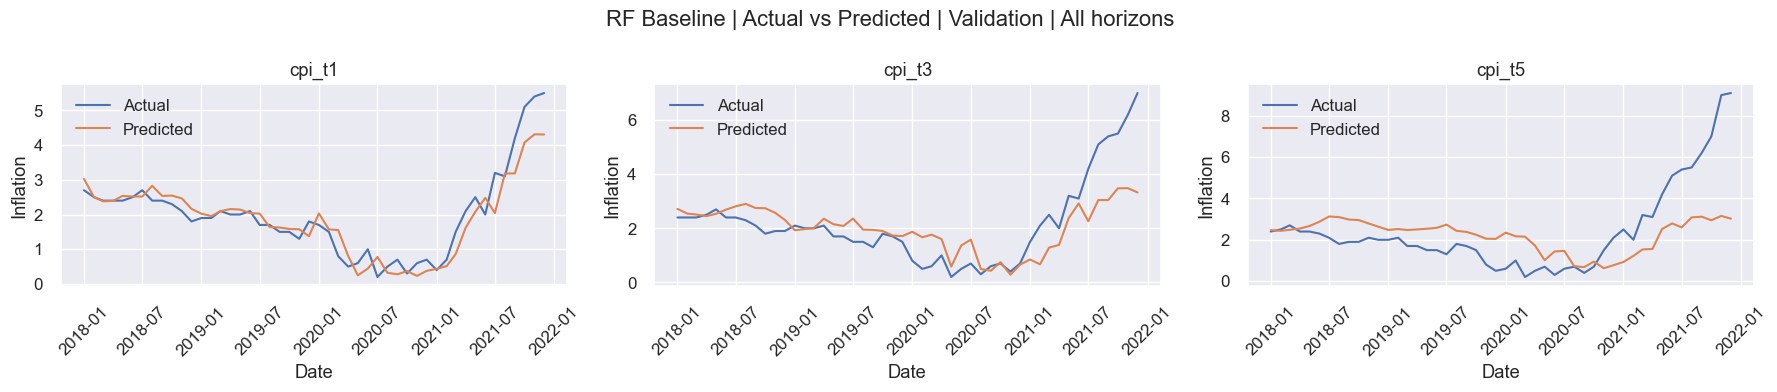

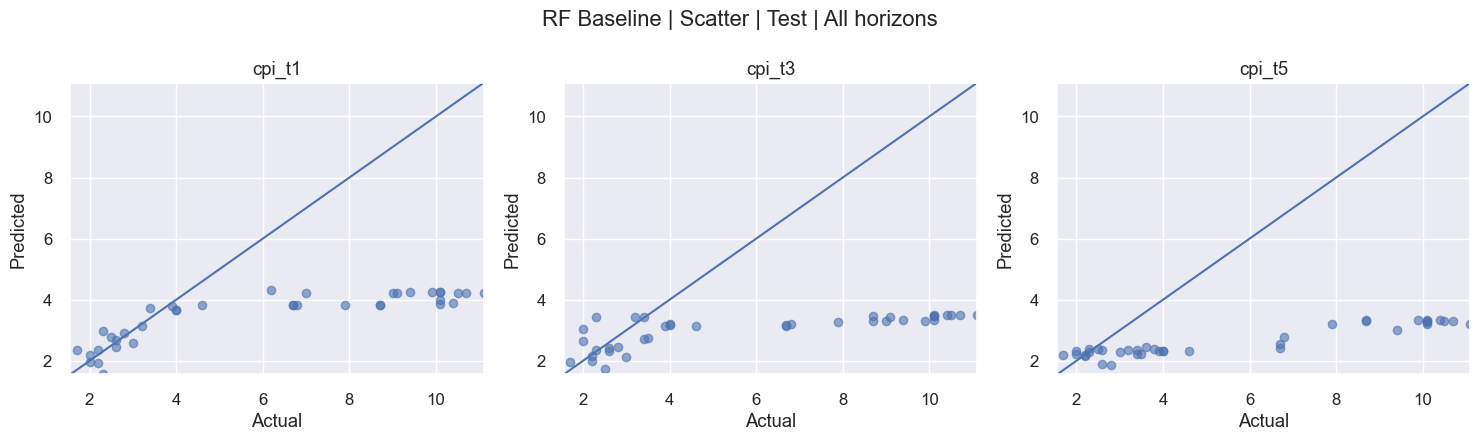

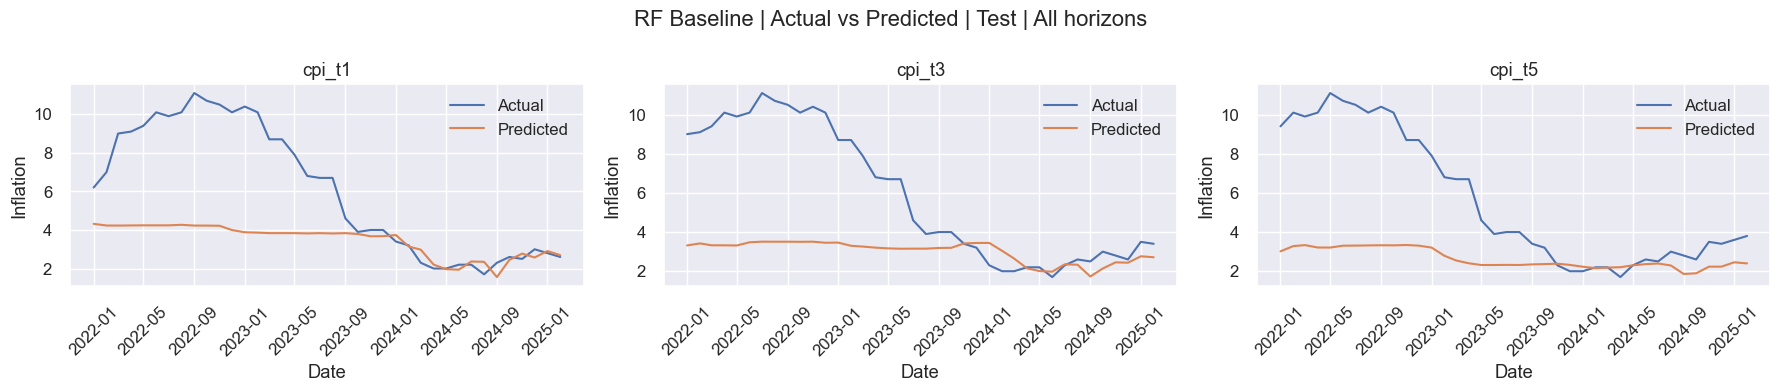

All combined plots displayed and saved to: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\artifacts\rf_baseline_plots


In [7]:
# ------------------------------------------------------------
# Step 4 : Visual Diagnostics (Show + Save)
#   - Saves ONE image with 3 subplots (t+1, t+3, t+5) for scatter
#   - Saves ONE image with 3 subplots (t+1, t+3, t+5) for line
# ------------------------------------------------------------

PLOTS_DIR = ARTIFACTS_DIR / "rf_baseline_plots"
PLOTS_DIR.mkdir(exist_ok=True)

def plot_scatter_grid(y_true_df, y_pred_df, split_name):
    """Create a single scatter figure with one subplot per horizon."""
    n = len(target_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
    axes = axes[0]

    # Consistent axis limits across horizons (helps comparison)
    global_min = float(min(y_true_df[target_cols].min().min(), y_pred_df[target_cols].min().min()))
    global_max = float(max(y_true_df[target_cols].max().max(), y_pred_df[target_cols].max().max()))
    lims = [global_min, global_max]

    for ax, tgt in zip(axes, target_cols):
        ax.scatter(y_true_df[tgt], y_pred_df[tgt], alpha=0.6)
        ax.plot(lims, lims)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(tgt)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    fig.suptitle(f"RF Baseline | Scatter | {split_name.capitalize()} | All horizons")
    fig.tight_layout()
    out_path = PLOTS_DIR / f"scatter_{split_name}_all_horizons.png"
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

def plot_line_grid(y_true_df, y_pred_df, dates, split_name):
    """Create a single line figure with one subplot per horizon."""
    n = len(target_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.0), squeeze=False, sharex=True)
    axes = axes[0]

    for ax, tgt in zip(axes, target_cols):
        ax.plot(dates, y_true_df[tgt], label="Actual")
        ax.plot(dates, y_pred_df[tgt], label="Predicted")
        ax.set_xlabel("Date")
        ax.set_ylabel("Inflation")
        ax.set_title(tgt)
        ax.tick_params(axis="x", rotation=45)
        ax.legend()

    fig.suptitle(f"RF Baseline | Actual vs Predicted | {split_name.capitalize()} | All horizons")
    fig.tight_layout()
    out_path = PLOTS_DIR / f"line_{split_name}_all_horizons.png"
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

# --------- Train ---------
plot_scatter_grid(y_train_df, rf_pred_train_df, "train")
plot_line_grid(y_train_df, rf_pred_train_df, df.loc[train_mask, "date"], "train")

# --------- Validation ---------
plot_scatter_grid(y_val_df, rf_pred_val_df, "validation")
plot_line_grid(y_val_df, rf_pred_val_df, df.loc[val_mask, "date"], "validation")

# --------- Test ---------
plot_scatter_grid(y_test_df, rf_pred_test_df, "test")
plot_line_grid(y_test_df, rf_pred_test_df, test_dates, "test")

print(f"All combined plots displayed and saved to: {PLOTS_DIR}")


### Random Forest Baseline — Metrics Summary (Train / Validation / Test)

The table below reports **MAE**, **RMSE**, and **R²** for each forecast horizon across the three temporal splits.


| Horizon | Split | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| cpi_t1 | train | 0.103 | 0.140 | 0.984 |
| cpi_t3 | train | 0.134 | 0.192 | 0.971 |
| cpi_t5 | train | 0.147 | 0.218 | 0.962 |
| cpi_t1 | validation | 0.337 | 0.462 | 0.853 |
| cpi_t3 | validation | 0.724 | 1.062 | 0.512 |
| cpi_t5 | validation | 1.312 | 1.822 | 0.213 |
| cpi_t1 | test | 2.724 | 3.713 | -0.274 |
| cpi_t3 | test | 3.069 | 4.148 | -0.545 |
| cpi_t5 | test | 3.044 | 4.116 | -0.571 |

*(Source: `artifacts/rf_baseline_metrics.csv`; values rounded to 3 d.p.)*